Theta0 = 49730.12213460003
Theta1 = 60802.5063835782


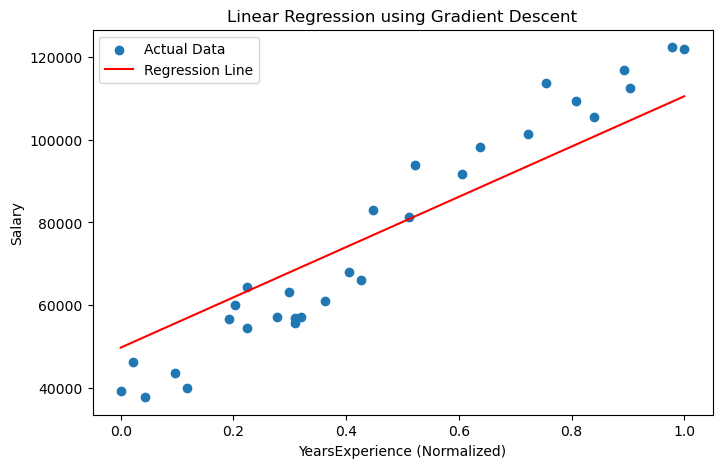

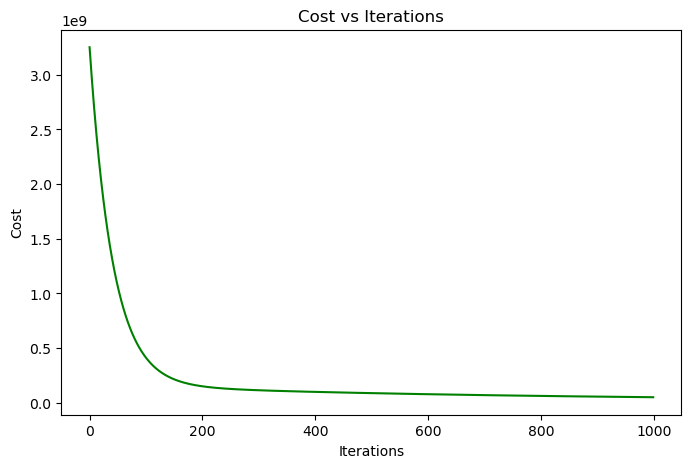

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset using full path
file_path = r'C:\Users\Shah Faisal\Downloads\New folder (2)\Salary_Data.csv'
data = pd.read_csv(file_path)

# Remove missing values
data = data.dropna()

# Input Feature and Target
X = data["YearsExperience"].values
y = data["Salary"].values

# Min-Max Normalization
X = (X - X.min()) / (X.max() - X.min())

# Initialize Parameters
theta0 = 0
theta1 = 0

# Hyperparameters
alpha = 0.01
iterations = 1000
m = len(X)

# Store Cost Values
cost_history = []

# Batch Gradient Descent
for i in range(iterations):

    # Prediction
    y_pred = theta0 + theta1 * X

    # Gradients
    d_theta0 = (1 / m) * np.sum(y_pred - y)
    d_theta1 = (1 / m) * np.sum((y_pred - y) * X)

    # Update Parameters
    theta0 = theta0 - alpha * d_theta0
    theta1 = theta1 - alpha * d_theta1

    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    cost_history.append(cost)

# Final Parameters
print("Theta0 =", theta0)
print("Theta1 =", theta1)

plt.figure(figsize=(8,5))
plt.scatter(X, y, label="Actual Data")
plt.plot(X, theta0 + theta1 * X, color='red', label="Regression Line")
plt.title("Linear Regression using Gradient Descent")
plt.xlabel("YearsExperience (Normalized)")
plt.ylabel("Salary")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(cost_history, color='green')
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Input and Target
X = data[["YearsExperience"]]
y = data["Salary"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Coefficient: [9423.81532303]
Intercept: 25321.583011776813
MSE: 49830096.85590839
R2 Score: 0.9024461774180497


In [8]:
# ==========================================
# TASK 3: Multivariate Linear Regression
# ==========================================

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Coefficients
for feature, coef in zip(housing.feature_names, model.coef_):
    print(feature, ":", coef)

MSE: 0.5558915986952442
R2 Score: 0.575787706032451
MedInc : 0.8523816881485071
HouseAge : 0.12238223843286661
AveRooms : -0.305115910646556
AveBedrms : 0.37113188284861964
Population : -0.002298412747941135
AveOccup : -0.03662363134691483
Latitude : -0.8966350465633479
Longitude : -0.868926816545622


In [9]:
# ==========================================
# TASK 4: Logistic Regression from Scratch
# ==========================================

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load Dataset
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

# Convert labels
# malignant = 1 , benign = 0
y = np.where(y == 0, 1, 0)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

m, n = X.shape

theta = np.zeros(n)
alpha = 0.01
iterations = 1000

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent
for _ in range(iterations):

    z = np.dot(X, theta)
    h = sigmoid(z)

    gradient = (1/m) * np.dot(X.T, (h - y))
    theta = theta - alpha * gradient

# Predictions
probs = sigmoid(np.dot(X, theta))
preds = (probs >= 0.5).astype(int)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y, preds))
print("Precision:", precision_score(y, preds))
print("Recall:", recall_score(y, preds))
print("F1:", f1_score(y, preds))
print(confusion_matrix(y, preds))

Accuracy: 0.9736379613356766
Precision: 0.958139534883721
Recall: 0.9716981132075472
F1: 0.9648711943793911
[[348   9]
 [  6 206]]


In [11]:
# ==========================================
# TASK 5: Customer Churn Prediction Model
# ==========================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load Data
file_path = r'C:\Users\Shah Faisal\Downloads\New folder (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv'
data = pd.read_csv(file_path)

# Remove Missing Values
data = data.dropna()

# Convert Target
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

# Fix TotalCharges column
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()

# Features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['Contract', 'InternetService']

X = data[num_features + cat_features]
y = data['Churn']

# Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression())
])

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
pipeline.fit(X_train, y_train)

# Save One File
joblib.dump(pipeline, "churn_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
